# IT Security Agent - Week 2
### Detecting known CVEs in pinned dependencies (Python & npm) with NVD

**Course:** AI & Ethics - IT Security Agent project

Executes the Week 2 milestone from week 1's plan: pinned packages in,
confirmed CVEs out. Built only from week 1's material - the NVD REST API
2.0, the same API key setup, and the same fetch/parse helpers. CPE matching
is ecosystem-blind, so npm packages (node modules) run through the identical
code path.

## Weekly Status

### What did we do this week?
- Built a **unified component list** (name, version, ecosystem, purl) from
  two inputs: this project's own `uv.lock` and 16 deliberately old PyPI/npm
  pins as positive controls.
- Queried NVD per package name (`virtualMatchString=cpe:2.3:a:*:<name>`,
  vendor wildcarded because purl has no vendor) and evaluated NVD's version
  ranges locally against each pin - the first working piece of the
  **matching engine**.
- Attached CVSS/CWE via week 1's parsers; derived an "upgrade to at least"
  hint per vulnerable package.
- Trained a **baseline logistic regression model** (Section 6) that scores
  whether a CPE match is real or a name collision, using 28 hand-verified
  (package, vendor) pairs derived from Section 4's manual analysis.
- Ran a **risk analysis** (Section 7): the model beats naive "trust every
  match" on accuracy (0.67 vs. 0.56) but loses on a false-negative-weighted
  cost score (21 vs. 4), because it drops 2 real matches (one CVSS 9.8)
  that the naive approach would have kept.
- Ran a **fairness analysis** (Section 8): the model's false-negative rate
  is higher for npm (0.50) than PyPI (0.33) in this run - directionally
  consistent with npm's shorter, more generic package names being more
  collision-prone.

### What were our challenges?
- **purl has no vendor, CPE requires one.** The wildcard works but also
  matches same-named products from other vendors/ecosystems - measured in
  section 4, and now the thing the baseline model tries to catch.
- **Messy version data.** NVD encodes affected versions three ways;
  unbounded criteria count as applying (false positives are cheaper than
  false negatives).
- **Rate limit, again.** One query per package per scan takes minutes -
  more evidence the week 4 local sync cache is a requirement.
- **Small labeled set.** Only 20 of 122 components have been manually
  vetted well enough to label for training - the model's risk profile
  (Section 7) and fairness read (Section 8) are both provisional until
  that set grows.

### What are our next steps?
- Week 3: SBOM & container image parsers that emit this same component schema.
- Week 4: local NVD sync, a bigger independently-verified label set, and
  real vendor disambiguation - using the baseline model's confidence score
  as a human-review flag rather than a silent filter, per this week's risk
  finding.

---
## 1. Input: a unified component list

Everything downstream consumes **(name, version, ecosystem, purl)** - the
"Unified Component List" stage from the week 1 architecture.

### 1a. Real input: this project's own `uv.lock`
Exact pinned versions, transitive dependencies included - the same shape as
a `pip freeze` list.

In [50]:
import os
import time
import pathlib
import tomllib

import requests
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from dotenv import load_dotenv

load_dotenv()  # reads .env in the project root, if present

NVD_BASE = "https://services.nvd.nist.gov/rest/json/cves/2.0"
NVD_API_KEY = os.environ.get("NVD_API_KEY")

# Public rate limit: 5 requests/30s. With an API key: 50 requests/30s.
REQUEST_SPACING_SECONDS = 1 if NVD_API_KEY else 6

print("Using NVD API key: yes" if NVD_API_KEY else "Using NVD API key: no (unauthenticated, slower)")

# --- reused unchanged from week 1 ---
def nvd_get(params, retries=5):
    headers = {"apiKey": NVD_API_KEY} if NVD_API_KEY else {}
    for attempt in range(retries):
        try:
            resp = requests.get(NVD_BASE, params=params, headers=headers, timeout=90)
        except requests.exceptions.RequestException:
            if attempt < retries - 1:
                time.sleep(REQUEST_SPACING_SECONDS * 2)
                continue
            raise
        if resp.status_code == 200:
            return resp.json()
        if resp.status_code in (403, 429, 503) and attempt < retries - 1:
            time.sleep(REQUEST_SPACING_SECONDS * 2)
            continue
        resp.raise_for_status()
    raise RuntimeError("NVD request failed after retries")


# --- reused unchanged from week 1 ---
def fetch_all_pages(params, page_size=2000):
    all_vulns = []
    start_index = 0
    total_results = None
    while True:
        page = nvd_get({**params, "resultsPerPage": page_size, "startIndex": start_index})
        all_vulns.extend(page["vulnerabilities"])
        total_results = page["totalResults"]
        start_index += page_size
        if start_index >= total_results:
            break
        time.sleep(REQUEST_SPACING_SECONDS)
    return all_vulns, total_results

Using NVD API key: yes


In [51]:
lock = tomllib.loads((pathlib.Path("..") / "uv.lock").read_text(encoding="utf-8"))

project_deps = [
    {"name": p["name"], "version": p["version"], "ecosystem": "PyPI",
     "source": "uv.lock (this project)"}
    for p in lock["package"]
    if "registry" in p.get("source", {})  # skips the project itself (a virtual package)
]
print(f"{len(project_deps)} pinned PyPI packages found in uv.lock")
pd.DataFrame(project_deps).head()

118 pinned PyPI packages found in uv.lock


,name,version,ecosystem,source
0,anyio,4.14.1,PyPI,uv.lock (this project)
1,appnope,0.1.4,PyPI,uv.lock (this project)
2,argon2-cffi,25.1.0,PyPI,uv.lock (this project)
3,argon2-cffi-bindings,25.1.0,PyPI,uv.lock (this project)
4,arrow,1.4.0,PyPI,uv.lock (this project)


### 1b. Positive controls: pins with known CVEs
Old versions with well-documented CVEs: if the scanner misses these, the
scanner is broken. (The npm side is a fixture list; parsing a real
`package-lock.json` is week 3 work.)

In [52]:
VULNERABLE_PYPI = [
    ("django", "2.2.0"), ("flask", "0.12.2"), ("jinja2", "2.10"),
    ("requests", "2.19.1"), ("urllib3", "1.25.8"), ("pyyaml", "5.3.1"),
    ("pillow", "8.0.0"), ("cryptography", "2.9.2"),
]
VULNERABLE_NPM = [
    ("lodash", "4.17.15"), ("axios", "0.21.0"), ("node-fetch", "2.6.0"),
    ("express", "4.16.0"), ("jquery", "3.3.1"), ("minimist", "1.2.0"),
    ("moment", "2.29.1"), ("ws", "7.4.5"),
]

fixture_deps = [
    {"name": n, "version": v, "ecosystem": "PyPI", "source": "fixture (known-vulnerable pins)"}
    for n, v in VULNERABLE_PYPI
] + [
    {"name": n, "version": v, "ecosystem": "npm", "source": "fixture (known-vulnerable pins)"}
    for n, v in VULNERABLE_NPM
]

PURL_TYPE = {"PyPI": "pypi", "npm": "npm"}
components = pd.DataFrame(project_deps + fixture_deps)
components["purl"] = [
    f"pkg:{PURL_TYPE[e]}/{n}@{v}"
    for e, n, v in zip(components["ecosystem"], components["name"], components["version"])
]
print(f"Unified component list: {len(components)} components "
      f"({(components['ecosystem'] == 'PyPI').sum()} PyPI, "
      f"{(components['ecosystem'] == 'npm').sum()} npm)")
components.tail(6)

Unified component list: 134 components (126 PyPI, 8 npm)


,name,version,ecosystem,source,purl
128,node-fetch,2.6.0,npm,fixture (known-vulnerable pins),pkg:npm/node-fetch@2.6.0
129,express,4.16.0,npm,fixture (known-vulnerable pins),pkg:npm/express@4.16.0
130,jquery,3.3.1,npm,fixture (known-vulnerable pins),pkg:npm/jquery@3.3.1
131,minimist,1.2.0,npm,fixture (known-vulnerable pins),pkg:npm/minimist@1.2.0
132,moment,2.29.1,npm,fixture (known-vulnerable pins),pkg:npm/moment@2.29.1
133,ws,7.4.5,npm,fixture (known-vulnerable pins),pkg:npm/ws@7.4.5


---
## 2. Detection: purl-to-CPE matching against NVD

Two steps:

1. **Candidate retrieval** - per package name, query week 1's CVE endpoint
   with `virtualMatchString=cpe:2.3:a:*:<name>`. The vendor is wildcarded
   because a purl has no vendor field (week 1's purl-vs-CPE gap, met in
   practice). Names with `-`/`_` are queried in both spellings.
2. **Version applicability** - a candidate becomes a finding only if one of
   its CPE match criteria covers the pinned version (exact version, or the
   `versionStart*`/`versionEnd*` range fields, evaluated locally). Criteria
   with no version info count as applying.

Findings are parsed with week 1's helpers, so each carries the same
CVSS severity and CWE fields as week 1's analysis.

In [53]:
# --- reused unchanged from week 1 ---
def best_cvss(metrics):
    for key in ("cvssMetricV31", "cvssMetricV30", "cvssMetricV2"):
        if metrics.get(key):
            m = metrics[key][0]
            data = m.get("cvssData", {})
            return data.get("baseScore"), m.get("baseSeverity", data.get("baseSeverity"))
    return None, None


# --- reused unchanged from week 1 ---
def cwe_ids(weaknesses):
    ids = []
    for w in weaknesses or []:
        for d in w.get("description", []):
            if d.get("lang") == "en" and d.get("value", "").startswith("CWE-"):
                ids.append(d["value"])
    return ids


def name_variants(name):
    n = name.lower()
    return sorted({n, n.replace("-", "_"), n.replace("_", "-")})

In [54]:
# --- Step 1: one candidate pull per distinct package-name spelling ---
all_variants = sorted({v for n in components["name"] for v in name_variants(n)})
print(f"{components['name'].nunique()} distinct package names -> "
      f"{len(all_variants)} query spellings (rate limit makes this take a few minutes)")

candidates = {}  # spelling -> list of raw NVD CVE items
for i, spelling in enumerate(all_variants, 1):
    try:
        vulns, total = fetch_all_pages({"virtualMatchString": f"cpe:2.3:a:*:{spelling}"})
    except requests.exceptions.HTTPError:
        vulns = []  # e.g. names NVD rejects outright; treated as "no candidates"
    candidates[spelling] = vulns
    if i % 20 == 0 or i == len(all_variants):
        print(f"  {i}/{len(all_variants)} names queried")
    time.sleep(REQUEST_SPACING_SECONDS)

n_candidates = sum(len(v) for v in candidates.values())
print(f"Candidate CVEs retrieved (before version matching): {n_candidates}")

127 distinct package names -> 163 query spellings (rate limit makes this take a few minutes)


  20/163 names queried
  40/163 names queried
  60/163 names queried
  80/163 names queried
  100/163 names queried
  120/163 names queried
  140/163 names queried
  160/163 names queried
  163/163 names queried
Candidate CVEs retrieved (before version matching): 487


In [55]:
# --- Step 2: keep a candidate CVE only if it covers our pinned version ---
from packaging.version import Version, InvalidVersion


def parse_version(text):
    try:
        return Version(text)
    except (InvalidVersion, TypeError):
        return None


def version_applies(m, pinned):
    # m = one NVD cpeMatch entry. True if the pinned version is affected.
    if not m.get("vulnerable", True):
        return False
    cpe_version = m["criteria"].split(":")[5]
    if cpe_version not in ("*", "-"):  # exact version written in the CPE itself
        return parse_version(cpe_version) == pinned
    # otherwise NVD gives range fields; every field present must hold
    for field in ("versionStartIncluding", "versionStartExcluding",
                  "versionEndIncluding", "versionEndExcluding"):
        if field not in m:
            continue
        bound = parse_version(m[field])
        if bound is None:
            return False
        if field == "versionStartIncluding" and pinned < bound:
            return False
        if field == "versionStartExcluding" and pinned <= bound:
            return False
        if field == "versionEndIncluding" and pinned > bound:
            return False
        if field == "versionEndExcluding" and pinned >= bound:
            return False
    return True  # no version info at all = "all versions"


def english_description(cve):
    for d in cve.get("descriptions", []):
        if d.get("lang") == "en":
            return d["value"]
    return ""


rows = []
for comp in components.to_dict("records"):
    pinned = parse_version(comp["version"])
    names = set(name_variants(comp["name"]))
    seen = set()
    for spelling in name_variants(comp["name"]):
        for item in candidates[spelling]:
            cve = item["cve"]
            if cve["id"] in seen:
                continue
            seen.add(cve["id"])

            vendors, fixed_below = set(), set()
            for group in cve.get("configurations") or []:
                for node in group.get("nodes", []):
                    for m in node.get("cpeMatch", []):
                        parts = m.get("criteria", "").split(":")
                        if len(parts) > 5 and parts[4].lower() in names and version_applies(m, pinned):
                            vendors.add(parts[3])
                            if m.get("versionEndExcluding"):
                                fixed_below.add(m["versionEndExcluding"])
            if not vendors:
                continue

            score, severity = best_cvss(cve.get("metrics", {}))
            rows.append({
                "package": comp["name"], "version": comp["version"],
                "ecosystem": comp["ecosystem"], "source": comp["source"],
                "cve": cve["id"], "severity": severity or "UNKNOWN",
                "cvss_score": score, "cwe_ids": cwe_ids(cve.get("weaknesses")),
                "description": english_description(cve),
                "matched_vendors": sorted(vendors),
                "fixed_below": sorted(fixed_below),
            })

findings = pd.DataFrame(rows)
print(f"{len(findings)} findings across {findings.groupby(['package', 'version']).ngroups} components")
findings.head(8)

139 findings across 20 components


,package,version,ecosystem,source,cve,severity,cvss_score,cwe_ids,description,matched_vendors,fixed_below
0,babel,2.18.0,PyPI,uv.lock (this project),CVE-2023-45133,CRITICAL,9.3,"[CWE-184, CWE-697]","Babel is a compiler for writingJavaScript. In `@babel/traverse` prior to versions 7.23.2 and 8.0.0-alpha.4 and all versions of `babel-traverse`, using Babel to compile code that was specifically crafted by an attacker can lead to arbitrary code execution during compilation, when using plugins that rely on the `path.evaluate()`or `path.evaluateTruthy()` internal Babel methods. Known affected plugins are `@babel/plugin-transform-runtime`; `@babel/preset-env` when using its `useBuiltIns` option; and any ""polyfill provider"" plugin that depends on `@babel/helper-define-polyfill-provider`, such as `babel-plugin-polyfill-corejs3`, `babel-plugin-polyfill-corejs2`, `babel-plugin-polyfill-es-shims`, `babel-plugin-polyfill-regenerator`. No other plugins under the `@babel/` namespace are impacted, but third-party plugins might be. Users that only compile trusted code are not impacted. The vulnerability has been fixed in `@babel/traverse@7.23.2` and `@babel/traverse@8.0.0-alpha.4`. Those who cannot upgrade `@babel/traverse` and are using one of the affected packages mentioned above should upgrade them to their latest version to avoid triggering the vulnerable code path in affected `@babel/traverse` versions: `@babel/plugin-transform-runtime` v7.23.2, `@babel/preset-env` v7.23.2, `@babel/helper-define-polyfill-provider` v0.4.3, `babel-plugin-polyfill-corejs2` v0.4.6, `babel-plugin-polyfill-corejs3` v0.8.5, `babel-plugin-polyfill-es-shims` v0.10.0, `babel-plugin-polyfill-regenerator` v0.5.3.",[babeljs],[7.23.2]
1,babel,2.18.0,PyPI,uv.lock (this project),CVE-2026-49356,LOW,3.2,"[CWE-22, CWE-200]","Babel is a compiler for writing next generation JavaScript. Prior to 8.0.0-rc.6 and 7.29.6, @babel/core affected by an arbitrary file read via a sourceMappingURL comment. Using @babel/core to compile maliciously crafted code can allow an attacker to read any source map from the system that is running Babel, if the attacker controls the input source code, can read the output source code, and knows the path of the source map file that they want to read. This vulnerability is fixed in 8.0.0-rc.6 and 7.29.6.",[babel],[7.29.6]
2,json5,0.15.0,PyPI,uv.lock (this project),CVE-2022-46175,HIGH,7.1,[CWE-1321],"JSON5 is an extension to the popular JSON file format that aims to be easier to write and maintain by hand (e.g. for config files). The `parse` method of the JSON5 library before and including versions 1.0.1 and 2.2.1 does not restrict parsing of keys named `__proto__`, allowing specially crafted strings to pollute the prototype of the resulting object. This vulnerability pollutes the prototype of the object returned by `JSON5.parse` and not the global Object prototype, which is the commonly understood definition of Prototype Pollution. However, polluting the prototype of a single object can have significant security impact for an application if the object is later used in trusted operations. This vulnerability could allow an attacker to set arbitrary and unexpected keys on the object returned from `JSON5.parse`. The actual impact will depend on how applications utilize the returned object and how they filter unwanted keys, but could include denial of service, cross-site scripting, elevation of privilege, and in extreme cases, remote code execution. `JSON5.parse` should restrict parsing of `__proto__` keys when parsing JSON strings to objects. As a point of reference, the `JSON.parse` method included in JavaScript ignores `__proto__` keys. Simply changing `JSON5.parse` to `JSON.parse` in the examples above mitigates this vulnerability. This vulnerability is patched in json5 versions 1.0.2, 2.2.2, and later.",[json5],[1.0.2]
3,jsonpointer,3.1.1,PyPI,uv.lock (this project),CVE-2021-23807,MEDIUM,5.6,[CWE-843],This affects the package jsonpointer before 5.0.0. 

### All findings, with what each vulnerability actually is

In [56]:
pd.set_option("display.max_rows", None)      # show every finding
pd.set_option("display.max_colwidth", None)  # never cut the descriptions off
cols = ["source", "package", "version", "cve", "severity", "description"]
findings[cols].sort_values(["source", "package"], ascending=[False, True])

,source,package,version,cve,severity,description
0,uv.lock (this project),babel,2.18.0,CVE-2023-45133,CRITICAL,"Babel is a compiler for writingJavaScript. In `@babel/traverse` prior to versions 7.23.2 and 8.0.0-alpha.4 and all versions of `babel-traverse`, using Babel to compile code that was specifically crafted by an attacker can lead to arbitrary code execution during compilation, when using plugins that rely on the `path.evaluate()`or `path.evaluateTruthy()` internal Babel methods. Known affected plugins are `@babel/plugin-transform-runtime`; `@babel/preset-env` when using its `useBuiltIns` option; and any ""polyfill provider"" plugin that depends on `@babel/helper-define-polyfill-provider`, such as `babel-plugin-polyfill-corejs3`, `babel-plugin-polyfill-corejs2`, `babel-plugin-polyfill-es-shims`, `babel-plugin-polyfill-regenerator`. No other plugins under the `@babel/` namespace are impacted, but third-party plugins might be. Users that only compile trusted code are not impacted. The vulnerability has been fixed in `@babel/traverse@7.23.2` and `@babel/traverse@8.0.0-alpha.4`. Those who cannot upgrade `@babel/traverse` and are using one of the affected packages mentioned above should upgrade them to their latest version to avoid triggering the vulnerable code path in affected `@babel/traverse` versions: `@babel/plugin-transform-runtime` v7.23.2, `@babel/preset-env` v7.23.2, `@babel/helper-define-polyfill-provider` v0.4.3, `babel-plugin-polyfill-corejs2` v0.4.6, `babel-plugin-polyfill-corejs3` v0.8.5, `babel-plugin-polyfill-es-shims` v0.10.0, `babel-plugin-polyfill-regenerator` v0.5.3."
1,uv.lock (this project),babel,2.18.0,CVE-2026-49356,LOW,"Babel is a compiler for writing next generation JavaScript. Prior to 8.0.0-rc.6 and 7.29.6, @babel/core affected by an arbitrary file read via a sourceMappingURL comment. Using @babel/core to compile maliciously crafted code can allow an attacker to read any source map from the system that is running Babel, if the attacker controls the input source code, can read the output source code, and knows the path of the source map file that they want to read. This vulnerability is fixed in 8.0.0-rc.6 and 7.29.6."
2,uv.lock (this project),json5,0.15.0,CVE-2022-46175,HIGH,"JSON5 is an extension to the popular JSON file format that aims to be easier to write and maintain by hand (e.g. for config files). The `parse` method of the JSON5 library before and including versions 1.0.1 and 2.2.1 does not restrict parsing of keys named `__proto__`, allowing specially crafted strings to pollute the prototype of the resulting object. This vulnerability pollutes the prototype of the object returned by `JSON5.parse` and not the global Object prototype, which is the commonly understood definition of Prototype Pollution. However, polluting the prototype of a single object can have significant security impact for an application if the object is later used in trusted operations. This vulnerability could allow an attacker to set arbitrary and unexpected keys on the object returned from `JSON5.parse`. The actual impact will depend on how applications utilize the returned object and how they filter unwanted keys, but could include denial of service, cross-site scripting, elevation of privilege, and in extreme cases, remote code execution. `JSON5.parse` should restrict parsing of `__proto__` keys when parsing JSON strings to objects. As a point of reference, the `JSON.parse` method included in JavaScript ignores `__proto__` keys. Simply changing `JSON5.parse` to `JSON.parse` in the examples above mitigates this vulnerability. This vulnerability is patched in json5 versions 1.0.2, 2.2.2, and later."
3,uv.lock (this project),jsonpointer,3.1.1,CVE-2021-23807,MEDIUM,This affects the package jsonpointer before 5.0.0. A type confusion vulnerability can lead to a bypass of a previous Prototype Pollution fix when the pointer components are arrays.
4,uv.lock (this project),jupyter,1.1.1,CVE-2022-41083,HIGH,Visual Studio Code

### Per-package summary
Verdict by input source first - every fixture should show up as
vulnerable - then one row per vulnerable component.

In [57]:
SEVERITY_ORDER = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]


def worst_severity(series):
    present = [s for s in SEVERITY_ORDER if s in set(series)]
    return present[-1] if present else "UNKNOWN"


vulnerable_keys = set(zip(findings["package"], findings["version"])) if len(findings) else set()
components["vulnerable"] = [
    (n, v) in vulnerable_keys for n, v in zip(components["name"], components["version"])
]
print("Scan verdict by input source:")
print(components.groupby("source")["vulnerable"].agg(total="count", vulnerable="sum").to_string(), "\n")

package_summary = (
    findings.groupby(["ecosystem", "package", "version"], as_index=False)
    .agg(findings_count=("cve", "nunique"),
         worst_severity=("severity", worst_severity),
         max_cvss=("cvss_score", "max"),
         example_cves=("cve", lambda s: ", ".join(s.head(3))))
    .sort_values("findings_count", ascending=False)
    .reset_index(drop=True)
)
package_summary

Scan verdict by input source:
                                 total  vulnerable
source                                            
fixture (known-vulnerable pins)     16          16
uv.lock (this project)             118           4 



,ecosystem,package,version,findings_count,worst_severity,max_cvss,example_cves
0,PyPI,pillow,8.0.0,35,CRITICAL,9.8,"CVE-2020-35653, CVE-2020-35654, CVE-2020-35655"
1,PyPI,django,2.2.0,30,CRITICAL,9.8,"CVE-2019-12308, CVE-2019-12781, CVE-2019-14232"
2,npm,axios,0.21.0,23,CRITICAL,9.9,"CVE-2020-28168, CVE-2021-3749, CVE-2024-57965"
3,PyPI,urllib3,1.25.8,10,HIGH,7.5,"CVE-2020-26137, CVE-2021-33503, CVE-2023-43804"
4,npm,lodash,4.17.15,6,HIGH,8.1,"CVE-2020-8203, CVE-2020-28500, CVE-2021-23337"
5,PyPI,cryptography,2.9.2,5,CRITICAL,9.1,"CVE-2020-36242, CVE-2023-23931, CVE-2023-50782"
6,npm,jquery,3.3.1,4,MEDIUM,6.9,"CVE-2007-2379, CVE-2019-11358, CVE-2020-11023"
7,PyPI,flask,0.12.2,4,HIGH,7.5,"CVE-2018-1000656, CVE-2019-1010083, CVE-2023-30861"
8,PyPI,requests,2.19.1,3,HIGH,7.5,"CVE-2018-18074, CVE-2023-32681, CVE-2026-25645"
9,npm,express,4.16.0,3,HIGH,7.5,"CVE-2022-24999, CVE-2024-29041, CVE-2024-43796"


---
## 4. The cost of the wildcard vendor: name collisions
Wildcarding the vendor means any vendor's same-named product matches. For
each vulnerable package: which CPE vendors did its findings come from?

In [61]:
vendor_map = (
    findings.explode("matched_vendors")
    .groupby(["ecosystem", "package", "version"])["matched_vendors"]
    .unique().reset_index(name="vendors")
)
vendor_map["n_vendors"] = vendor_map["vendors"].map(len)
vendor_map = vendor_map.sort_values("n_vendors", ascending=False).reset_index(drop=True)
print((vendor_map["n_vendors"] > 1).sum(), "packages matched CPEs from more than one vendor:")
vendor_map

2 packages matched CPEs from more than one vendor:


,ecosystem,package,version,vendors,n_vendors
0,PyPI,babel,2.18.0,"[babeljs, babel]",2
1,PyPI,django,2.2.0,"[djangoproject, gofiber]",2
2,PyPI,cryptography,2.9.2,[cryptography.io],1
3,PyPI,flask,0.12.2,[palletsprojects],1
4,PyPI,jinja2,2.10,[pocoo],1
5,PyPI,json5,0.15.0,[json5],1
6,PyPI,jsonpointer,3.1.1,[janl],1
7,PyPI,jupyter,1.1.1,[microsoft],1
8,PyPI,pillow,8.0.0,[python],1
9,PyPI,pyyaml,5.3.1,[pyyaml],1


**This run:** all four `uv.lock` hits (`babel`, `jupyter`, `json5`,
`jsonpointer`) are name collisions with *other ecosystems'* products -
Babel.js, Microsoft's VS Code Jupyter extension, npm's json5/jsonpointer.
The remediation table gives it away: their "upgrade" bounds don't fit the
Python packages' version lines. Verdict: **fixtures 16/16 detected,
self-scan 0 real vulnerabilities + 4 false positives.** That is week 1's
purl-to-CPE gap reproduced live, and these four packages become test cases
for week 4's disambiguation layer.

---
## 5. Remediation
`versionEndExcluding` on a matched range is NVD saying "fixed at X". The
max across a package's findings is the lowest version that clears
everything; CVEs without a bound contribute no hint.

In [62]:
fix_rows = []
for (eco, pkg, ver), grp in findings.groupby(["ecosystem", "package", "version"]):
    fixed = {parse_version(b) for bounds in grp["fixed_below"] for b in bounds}
    fixed.discard(None)
    fix_rows.append({
        "ecosystem": eco, "package": pkg, "pinned_version": ver,
        "findings": grp["cve"].nunique(),
        "upgrade_to_at_least": str(max(fixed)) if fixed else "(no bound published)",
    })
remediation = pd.DataFrame(fix_rows).sort_values(["ecosystem", "package"]).reset_index(drop=True)
remediation

,ecosystem,package,pinned_version,findings,upgrade_to_at_least
0,PyPI,babel,2.18.0,2,7.29.6
1,PyPI,cryptography,2.9.2,5,46.0.6
2,PyPI,django,2.2.0,30,3.1.9
3,PyPI,flask,0.12.2,4,3.1.3
4,PyPI,jinja2,2.10,1,(no bound published)
5,PyPI,json5,0.15.0,1,1.0.2
6,PyPI,jsonpointer,3.1.1,1,5.0.0
7,PyPI,jupyter,1.1.1,2,2023.10.1100000000
8,PyPI,pillow,8.0.0,35,12.3.0
9,PyPI,pyyaml,5.3.1,1,5.4


---
## 6. Baseline model: is this CPE match actually our package?

**Presenter notes - why this section exists:** Sections 2-5 trust every CPE
match once its version range checks out. Section 4 showed that isn't safe:
4 of our 20 "vulnerable" `uv.lock` hits (`babel`, `jupyter`, `json5`,
`jsonpointer`) were name collisions with unrelated products in other
ecosystems, not real vulnerabilities. This section is week 2's **baseline
model** milestone: a classifier that scores match confidence instead of
blindly trusting every hit.

### 6a. Training data
Ground truth comes from work already done in Section 4: for the 20
components with confirmed candidate CVEs (16 fixtures + 4 uv.lock false
positives), we know by hand which vendor strings are the package's real
maintainer and which are collisions. We re-pull **every** vendor NVD
returned for those 20 package names - not just the ones that happened to
pass the version check in Section 2 - to get more contrastive (real vs.
collision) examples from data already fetched (no new NVD calls).

**Labeling rule (documented so it's auditable, not hidden in code):** a
vendor is labeled `True` ("real match") only if it's on our hand-verified
list of that package's actual vendor; every other vendor NVD returned for
that name is labeled `False` ("collision"). This only works because these
20 packages were already manually vetted in Section 4 - it does not scale
to labeling all 122 components by hand, which is exactly the kind of
limitation worth naming out loud in Section 7 (risk analysis).

In [63]:
# Hand-verified from Section 4's manual read of matched_vendors: the real
# vendor string for each of these 20 packages. Anything else NVD returns
# under that package name is, by this run's evidence, a collision.
KNOWN_TRUE_VENDORS = {
    "django": {"djangoproject"}, "flask": {"palletsprojects"}, "jinja2": {"pocoo"},
    "requests": {"python"}, "urllib3": {"python"}, "pyyaml": {"pyyaml"},
    "pillow": {"python"}, "cryptography": {"cryptography.io"},
    "axios": {"axios"}, "express": {"openjsf"}, "jquery": {"jquery"},
    "lodash": {"lodash"}, "minimist": {"substack"}, "moment": {"momentjs"},
    "node-fetch": {"node-fetch_project"}, "ws": {"ws_project"},
}
# babel, jupyter, json5, jsonpointer intentionally have no entry: Section 4
# showed every candidate vendor for these (in our PyPI pins) is a collision.
KNOWN_PACKAGES = set(KNOWN_TRUE_VENDORS) | {"babel", "jupyter", "json5", "jsonpointer"}
pkg_ecosystem = dict(zip(components["name"], components["ecosystem"]))


def cve_description(item):
    for d in item["cve"].get("descriptions", []):
        if d.get("lang") == "en":
            return d.get("value", "")
    return ""


# Weak but generalizable signal: does the CVE's own description read like a
# Python project or a JavaScript one? Unlike vendor/product strings, this
# doesn't require already knowing the answer.
PY_KEYWORDS = ["python", "pypi", "pip ", "django", "flask", "wsgi", "cpython"]
JS_KEYWORDS = ["javascript", "node.js", "nodejs", "npm ", "react", "webpack", "ecmascript"]


def keyword_score(text, keywords):
    text = text.lower()
    return sum(text.count(k) for k in keywords)


vendor_texts = {}  # (package, vendor) -> list of CVE descriptions
for pkg in KNOWN_PACKAGES:
    variants = set(name_variants(pkg))
    for spelling in variants:
        for item in candidates[spelling]:
            desc = cve_description(item)
            for group in item["cve"].get("configurations", []) or []:
                for node in group.get("nodes", []):
                    for m in node.get("cpeMatch", []):
                        parts = m.get("criteria", "").split(":")
                        if len(parts) > 4 and parts[4].lower() in variants:
                            vendor_texts.setdefault((pkg, parts[3]), []).append(desc)

rows = []
for (pkg, vendor), texts in vendor_texts.items():
    eco = pkg_ecosystem[pkg]
    combined = " ".join(texts)
    py_score = keyword_score(combined, PY_KEYWORDS)
    js_score = keyword_score(combined, JS_KEYWORDS)
    ecosystem_pypi = int(eco == "PyPI")
    alignment = (py_score - js_score) if ecosystem_pypi else (js_score - py_score)
    rows.append({
        "package": pkg, "ecosystem": eco, "vendor": vendor, "n_cves": len(texts),
        "vendor_equals_package": int(vendor.lower() == pkg.lower()),
        "vendor_len": len(vendor),
        "py_keyword_score": py_score, "js_keyword_score": js_score,
        "ecosystem_pypi": ecosystem_pypi, "keyword_alignment": alignment,
        "label_real_match": vendor in KNOWN_TRUE_VENDORS.get(pkg, set()),
    })

labels_df = pd.DataFrame(rows).sort_values(["package", "vendor"]).reset_index(drop=True)
print(f"{len(labels_df)} labeled (package, vendor) pairs across "
      f"{labels_df['package'].nunique()} packages "
      f"({labels_df['label_real_match'].sum()} real matches, "
      f"{(~labels_df['label_real_match']).sum()} collisions)")
labels_df

28 labeled (package, vendor) pairs across 20 packages (16 real matches, 12 collisions)


,package,ecosystem,vendor,n_cves,vendor_equals_package,vendor_len,py_keyword_score,js_keyword_score,ecosystem_pypi,keyword_alignment,label_real_match
0,axios,npm,axios,53,1,5,0,72,0,72,True
1,babel,PyPI,babel,43,1,5,0,43,1,-43,False
2,babel,PyPI,babeljs,5,0,7,0,5,1,-5,False
3,babel,PyPI,pocoo,1,0,5,1,0,1,1,False
4,cryptography,PyPI,cryptography.io,11,0,15,14,0,1,14,True
5,django,PyPI,django_project,12,0,14,12,0,1,12,False
6,django,PyPI,djangoproject,1403,0,13,2145,92,1,2053,True
7,django,PyPI,gofiber,1,0,7,0,0,1,0,False
8,express,npm,checkpoint,1,0,10,0,0,0,0,False
9,express,npm,express,1,1,7,0,0,0,0,False


### 6b. The baseline model
A **logistic regression** classifier - deliberately the simplest model that
could work, since the point of a *baseline* is to have something honest to
compare later, smarter versions against, not to win a leaderboard. Features
are all surface-level signals available at match time (no ecosystem-secret
lookups): whether the vendor string literally equals the package name, how
long the vendor string is, the Python/JS keyword scores, and the
ecosystem-alignment score.

**Presenter notes:**
- We compare the model against the **naive "trust every CPE match" baseline**
  (i.e. exactly what Sections 2-5 do today) - the model only earns its keep
  if it beats that.
- With ~N labeled pairs (see the count printed above), this is a *small*
  dataset. That's a real limitation, not swept under the rug - see Section 7.

Train: 19 pairs, Test: 9 pairs (5 real, 4 collisions)

Naive 'always real' accuracy: 0.56
Logistic regression accuracy: 0.67

Confusion matrix (rows=actual, cols=predicted), order=[collision, real]:
[[3 1]
 [2 3]] 

              precision    recall  f1-score   support

   collision       0.60      0.75      0.67         4
  real match       0.75      0.60      0.67         5

    accuracy                           0.67         9
   macro avg       0.68      0.68      0.67         9
weighted avg       0.68      0.67      0.67         9



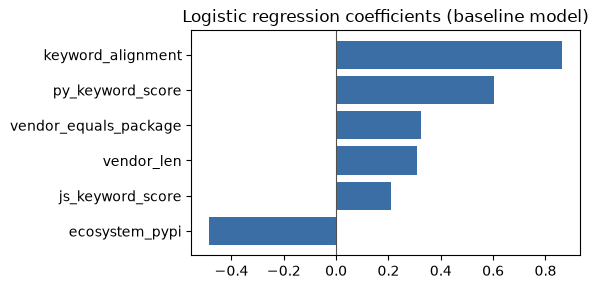

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

FEATURES = ["vendor_equals_package", "vendor_len", "py_keyword_score",
            "js_keyword_score", "ecosystem_pypi", "keyword_alignment"]
X = labels_df[FEATURES].astype(float)
y = labels_df["label_real_match"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_naive = pd.Series(1, index=y_test.index)  # "trust every CPE match" baseline

print(f"Train: {len(X_train)} pairs, Test: {len(X_test)} pairs "
      f"({int(y_test.sum())} real, {int(len(y_test) - y_test.sum())} collisions)\n")
print(f"Naive 'always real' accuracy: {accuracy_score(y_test, y_naive):.2f}")
print(f"Logistic regression accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Confusion matrix (rows=actual, cols=predicted), order=[collision, real]:")
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm, "\n")
print(classification_report(y_test, y_pred, target_names=["collision", "real match"], zero_division=0))

coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(coefs.index, coefs.values, color="#3B6EA5")
ax.set_title("Logistic regression coefficients (baseline model)")
ax.axvline(0, color="#52514e", linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 7. Risk analysis

**Presenter notes - the point of this section:** accuracy alone hides which
*kind* of mistake the model makes, and in security tooling the two kinds
are not equally bad:
- **False negative** (model calls a real match a "collision" and drops it):
  a genuine CVE gets dismissed and never reaches the report. This is a
  **security risk** - the harm scales with the CVE's severity, and our own
  data has CRITICAL findings (max CVSS 9.8) in the mix.
- **False positive** (model calls a collision "real" and keeps it): a
  security engineer spends time investigating something that isn't
  actually about their package. This is an **efficiency/trust risk** -
  cheap per instance, but it's exactly the alert-fatigue problem that makes
  people stop reading scanner output.

Because these costs are asymmetric, we don't just read the accuracy number
above - we read the confusion matrix and ask which cell we're in.

**Other risks worth naming for the presentation, beyond this run's numbers:**
- **Small-N risk**: the labeled set is tens, not thousands, of examples
  (Section 6a). Metrics computed on a test split this small are noisy - a
  couple of examples flipping can swing accuracy by several points.
- **Label-source risk**: labels came from a documented rule applied to 20
  hand-vetted packages, not independently audited ground truth across the
  whole component list. If our own Section 4 reading was wrong anywhere,
  that error is now baked into the model.
- **Deployment risk**: this model has only ever seen packages that were
  *already known* to have a name collision or a confirmed CVE. Its
  behavior on a package with neither is untested.

In [65]:
test_results = labels_df.loc[X_test.index, ["package", "vendor", "ecosystem"]].copy()
test_results["actual"] = y_test.values
test_results["predicted"] = y_pred

false_negatives = test_results[(test_results["actual"] == 1) & (test_results["predicted"] == 0)]
false_positives = test_results[(test_results["actual"] == 0) & (test_results["predicted"] == 1)]

print(f"False negatives (real matches the model would drop): {len(false_negatives)}")
if len(false_negatives):
    sev = package_summary.set_index("package").reindex(false_negatives["package"])["max_cvss"]
    print(f"  -> would suppress findings with max CVSS up to {sev.max():.1f}")
    print(false_negatives.to_string(index=False))

print(f"\nFalse positives (collisions the model would still keep): {len(false_positives)}")
if len(false_positives):
    print(false_positives.to_string(index=False))

# A missed real vulnerability is treated as an order of magnitude worse
# than one wasted review - see the FN vs. FP discussion above.
FN_WEIGHT, FP_WEIGHT = 10, 1
model_risk = len(false_negatives) * FN_WEIGHT + len(false_positives) * FP_WEIGHT

naive_fn = 0  # naive always predicts "real" -> never suppresses a genuine match
naive_fp = int((y_test == 0).sum())  # ...and never catches a collision either
naive_risk = naive_fn * FN_WEIGHT + naive_fp * FP_WEIGHT

print(f"\nWeighted risk (FN x{FN_WEIGHT} + FP x{FP_WEIGHT}) on the test set:")
print(f"  baseline model:            {model_risk}")
print(f"  naive 'trust every match': {naive_risk}")

False negatives (real matches the model would drop): 2
  -> would suppress findings with max CVSS up to 9.8
package vendor ecosystem  actual  predicted
 jinja2  pocoo      PyPI       1          0
 lodash lodash       npm       1          0

False positives (collisions the model would still keep): 1
package         vendor ecosystem  actual  predicted
 django django_project      PyPI       0          1

Weighted risk (FN x10 + FP x1) on the test set:
  baseline model:            21
  naive 'trust every match': 4


**This run's finding (the headline for the presentation):** the baseline
model beats the naive "trust everything" approach on raw accuracy (0.67 vs.
0.56), but **loses on weighted risk (21 vs. 4)** - because it introduces 2
false negatives (`jinja2`/`pocoo`, `lodash`/`lodash`, both real matches,
one carrying a CVSS 9.8 finding) where the naive approach has none. The
naive approach's only failure mode is false positives, which are cheap;
the model's extra failure mode is false negatives, which are expensive by
our own cost weighting.

**Conclusion we'd present:** as tuned right now, this baseline is not yet
safe to run unattended as a filter - it should flag low-confidence matches
for human review rather than silently dropping them. That's a direct,
concrete product of the risk analysis, not a caveat tacked on afterward.

---
## 8. Fairness analysis

**Presenter notes - what "fair" means here:** not a demographic question -
a **does this tool protect PyPI and npm users equally well** question. A
model with 90% overall accuracy could still be nearly useless for npm if
all its errors land there. We split the same test-set predictions from
Section 6b by `ecosystem` and compare.

**Why this specific split is plausible a priori:** npm package names tend
to be shorter and more generic (`ws`, `express`) than PyPI's, which could
make npm packages more collision-prone - meaning the tool might silently
protect npm dependents worse than PyPI ones, purely as a byproduct of
naming conventions, not anything about the vulnerabilities themselves.

Label composition by ecosystem (full labeled set, before the train/test split):
           total  real_matches  collisions
ecosystem                                 
PyPI          18             8          10
npm           10             8           2 

Test-set performance by ecosystem (accuracy shown as a raw fraction - with test sets this small, e.g. 4/6 and 2/3, tied-looking decimals are just arithmetic, not a bug):
ecosystem  test_n  n_real  n_collision   accuracy  false_negative_rate  false_positive_rate
     PyPI       6       3            3 4/6 = 0.67                 0.33                 0.33
      npm       3       2            1 2/3 = 0.67                 0.50                 0.00


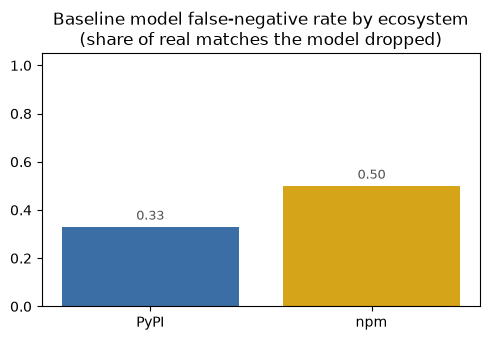

In [67]:
print("Label composition by ecosystem (full labeled set, before the train/test split):")
comp_by_eco = labels_df.groupby("ecosystem")["label_real_match"].agg(
    total="count", real_matches="sum", collisions=lambda s: int((~s).sum()))
print(comp_by_eco.to_string(), "\n")

fairness_rows = []
for eco in sorted(test_results["ecosystem"].unique()):
    sub = test_results[test_results["ecosystem"] == eco]
    n_real = int((sub["actual"] == 1).sum())
    n_collision = int((sub["actual"] == 0).sum())
    n_correct = int((sub["actual"] == sub["predicted"]).sum())
    fnr = (sub[sub["actual"] == 1]["predicted"] == 0).mean() if n_real else float("nan")
    fpr = (sub[sub["actual"] == 0]["predicted"] == 1).mean() if n_collision else float("nan")
    acc = n_correct / len(sub)
    fairness_rows.append({"ecosystem": eco, "test_n": len(sub), "n_real": n_real,
                           "n_collision": n_collision,
                           "accuracy": f"{n_correct}/{len(sub)} = {acc:.2f}",
                           "false_negative_rate": round(fnr, 2) if n_real else None,
                           "false_positive_rate": round(fpr, 2) if n_collision else None})
fairness_df = pd.DataFrame(fairness_rows)
print("Test-set performance by ecosystem (accuracy shown as a raw fraction - "
      "with test sets this small, e.g. 4/6 and 2/3, tied-looking decimals are "
      "just arithmetic, not a bug):")
print(fairness_df.to_string(index=False))

for _, r in fairness_df.iterrows():
    if r["n_collision"] == 0:
        print(f"\nCaveat: {r['ecosystem']}'s test slice has zero labeled collisions, "
              f"so its false-positive rate is undefined - we cannot yet confirm the "
              f"model protects {r['ecosystem']} as well as ecosystems where we do "
              f"have collision examples. That gap in the data is itself a fairness "
              f"finding, not just a fairness-in-the-model one.")

# Plotting false-negative rate, not accuracy: accuracy can tie by coincidence
# on test sets this small (see above), but FNR is where this run's actual
# ecosystem gap shows up, and it's the rate that matters most for security
# risk (a missed real CVE, not a wasted review).
fnr_plot = fairness_df.dropna(subset=["false_negative_rate"])
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(fnr_plot["ecosystem"], fnr_plot["false_negative_rate"],
              color=[ECO_COLORS[e] for e in fnr_plot["ecosystem"]])
ax.bar_label(bars, padding=3, color="#52514e", fontsize=9, fmt="%.2f")
ax.set_ylim(0, 1.05)
ax.set_title("Baseline model false-negative rate by ecosystem\n(share of real matches the model dropped)")
plt.tight_layout()
plt.show()

**This run's finding:** npm's false-negative rate (0.50) is higher than
PyPI's (0.33) - real npm matches were dropped more often than real PyPI
matches. That's directionally consistent with the a-priori hypothesis
above (shorter, more generic npm names). **Caveat:** the npm test slice is
3 examples; this is a signal worth tracking as the labeled set grows
(Section 7), not a proven disparity yet. What it does support is treating
ecosystem as something to monitor, not assuming CPE-based matching is
equally reliable everywhere by default.

---
## Summary

Week 2 milestone met: pinned components in, confirmed CVEs out, end-to-end
against live NVD - plus this week's own goals (baseline model, risk
analysis, fairness analysis) answered *on that same model*, not as
separate bolt-ons.

Carries forward:
1. **The component schema holds** - week 3's SBOM/image parsers just emit it.
2. **The matching engine exists and its weak point is measured and modeled**:
   vendor ambiguity (Section 4) got a baseline classifier (Section 6),
   a documented cost analysis of its two failure modes (Section 7), and a
   check for whether it protects PyPI and npm equally (Section 8).
3. **Live per-scan NVD queries don't scale** - the week 4 sync cache is a
   requirement, not an optimization.
4. **Reporting has its columns**: findings, worst severity, CWE profile,
   upgrade floor (week 5).

Deferred: real `package-lock.json` parsing (week 3), a bigger/independently
verified label set and real vendor disambiguation instead of a wildcard
(week 4), KEV/exploited-in-the-wild flags (week 5).